# Image Classification — Intel Image Classification Dataset

Dataset: [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)  
Classes: **buildings, forest, glacier, mountain, sea, street**  
Model: CNN Sequential dengan Conv2D + MaxPooling2D

## 1. Import Libraries

In [1]:
import os
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Gabungkan & Split Dataset Secara Mandiri

Dataset diunduh sudah punya folder `seg_train` dan `seg_test` bawaan, tapi sesuai ketentuan submission, split **tidak boleh** memakai pembagian bawaan tersebut. Semua gambar digabung dulu ke satu folder per kelas, lalu displit ulang secara mandiri (stratified) memakai `split-folders` menjadi **train (80%) / val (10%) / test (10%)**.

In [3]:
!pip install split-folders

In [4]:
import os, shutil, zipfile

ZIP_PATH      = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification/dataset/intel-image-classification.zip'
EXTRACT_PATH  = './dataset'
COMBINED_PATH = './combined'

if not os.path.exists(os.path.join(EXTRACT_PATH, 'seg_train')):
    print('Mengekstrak dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
    print('Ekstrak selesai!')
else:
    print('Dataset sudah diekstrak, skip.')

TRAIN_SRC = os.path.join(EXTRACT_PATH, 'seg_train', 'seg_train')
TEST_SRC  = os.path.join(EXTRACT_PATH, 'seg_test', 'seg_test')

CLASS_NAMES = sorted(os.listdir(TRAIN_SRC))
print('Classes:', CLASS_NAMES)
print('Jumlah kelas:', len(CLASS_NAMES))

# Gabungkan seluruh gambar dari seg_train + seg_test ke satu folder per kelas
if os.path.exists(COMBINED_PATH):
    shutil.rmtree(COMBINED_PATH)
os.makedirs(COMBINED_PATH, exist_ok=True)

for cls in CLASS_NAMES:
    dst_dir = os.path.join(COMBINED_PATH, cls)
    os.makedirs(dst_dir, exist_ok=True)
    for src_root in [TRAIN_SRC, TEST_SRC]:
        src_dir = os.path.join(src_root, cls)
        prefix  = os.path.basename(src_root)
        for fname in os.listdir(src_dir):
            src_file = os.path.join(src_dir, fname)
            dst_file = os.path.join(dst_dir, f'{prefix}_{fname}')
            shutil.copy2(src_file, dst_file)

print('\nGabung selesai. Jumlah gambar per kelas (gabungan):')
total = 0
for cls in CLASS_NAMES:
    n = len(os.listdir(os.path.join(COMBINED_PATH, cls)))
    total += n
    print(f'  {cls}: {n}')
print(f'Total gabungan: {total}')

Mengekstrak dataset...
Ekstrak selesai!
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Jumlah kelas: 6

Gabung selesai. Jumlah gambar per kelas (gabungan):
  buildings: 2628
  forest: 2745
  glacier: 2957
  mountain: 3037
  sea: 2784
  street: 2883
Total gabungan: 17034


Split dataset gabungan menjadi **train / val / test** secara mandiri dan proporsional (stratified per kelas) memakai `splitfolders`.

In [5]:
import splitfolders

SPLIT_PATH = './split_dataset'
if os.path.exists(SPLIT_PATH):
    shutil.rmtree(SPLIT_PATH)

splitfolders.ratio(COMBINED_PATH, output=SPLIT_PATH, seed=SEED, ratio=(.8, .1, .1))

TRAIN_DIR = os.path.join(SPLIT_PATH, 'train')
VAL_DIR   = os.path.join(SPLIT_PATH, 'val')
TEST_DIR  = os.path.join(SPLIT_PATH, 'test')

print('Jumlah gambar per split:')
total_test = 0
for split_name, split_dir in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    split_total = sum(len(os.listdir(os.path.join(split_dir, cls))) for cls in CLASS_NAMES)
    if split_name == 'test':
        total_test = split_total
    print(f'  {split_name}: {split_total}')

Copying files: 17034 files [00:03, 4556.68 files/s]

Jumlah gambar per split:
  train: 13625
  val: 1700
  test: 1709


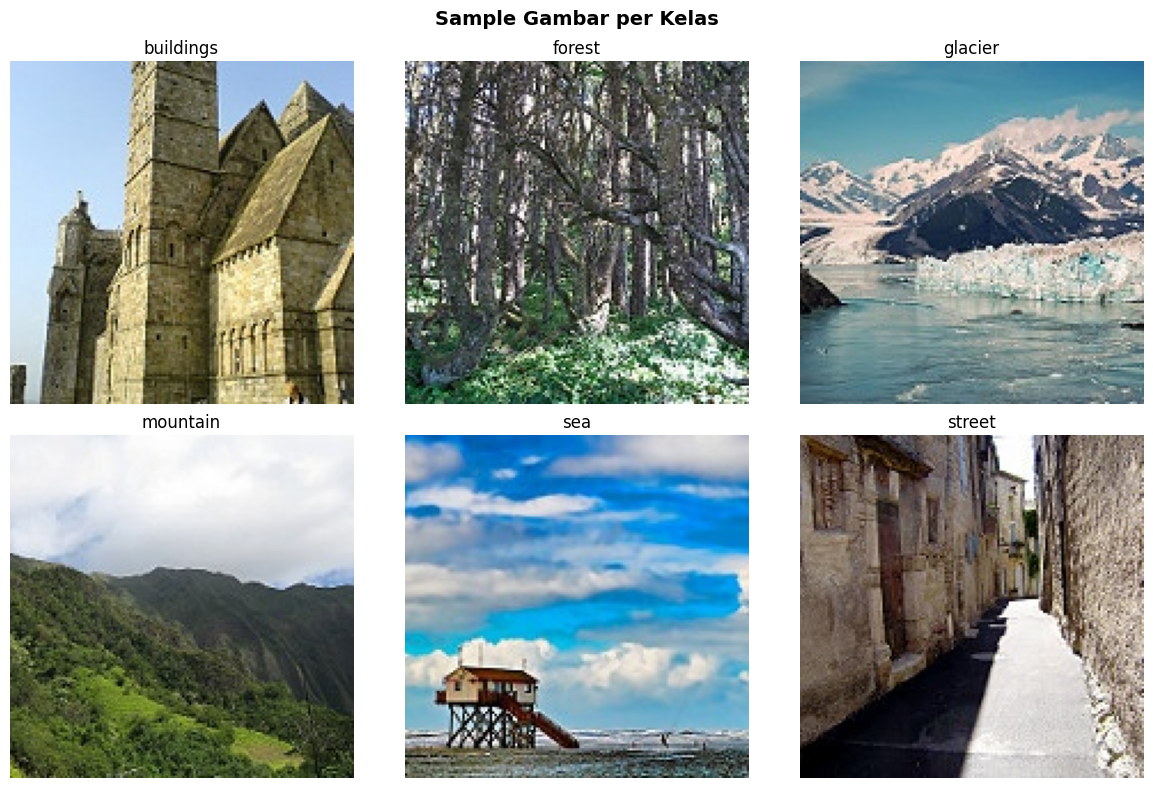

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir  = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img      = plt.imread(os.path.join(cls_dir, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=12)
    axes[i].axis('off')

plt.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing & Data Augmentation

- Ukuran gambar: **150x150**
- Train set: augmentasi (flip, rotation, zoom, shear)
- Validation & Test set: hanya rescale
- Sumber data sekarang dari `split_dataset/train`, `split_dataset/val`, `split_dataset/test` (hasil split mandiri di atas, bukan folder bawaan dataset)

In [7]:
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Class indices:', train_generator.class_indices)

Found 13625 images belonging to 6 classes.
Found 1700 images belonging to 6 classes.
Found 1709 images belonging to 6 classes.
Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


## 5. Membangun Model CNN (Sequential)

Arsitektur: 4 blok Conv2D + MaxPooling2D → Flatten → Dense → Dropout → Softmax

In [8]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
], name='intel_cnn')

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "intel_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,814,534 (26.00 MB)

 Trainable params: 6,814,534 (26.00 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile & Training

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/15
426/426 ━━━━━━━━━━━━━━━━━━━━ 112s 245ms/step - accuracy: 0.5245 - loss: 1.1698 - val_accuracy: 0.7153 - val_loss: 0.7762 - learning_rate: 0.0010
Epoch 2/15
426/426 ━━━━━━━━━━━━━━━━━━━━ 93s 218ms/step - accuracy: 0.6597 - loss: 0.8988 - val_accuracy: 0.7312 - val_loss: 0.7319 - learning_rate: 0.0010
Epoch 3/15
426/426 ━━━━━━━━━━━━━━━━━━━━ 95s 224ms/step - accuracy: 0.7151 - loss: 0.7796 - val_accuracy: 0.8118 - val_loss: 0.5272 - learning_rate: 0.0010
Epoch 4/15
426/426 ━━━━━━━━━━━━━━━━━━━━ 94s 220ms/step - accuracy: 0.7368 - loss: 0.7225 - val_accuracy: 0.8153 - val_loss: 0.5165 - learning_rate: 0.0010
Epoch 5/15
426/426 ━━━━━━━━━━━━━━━━━━━━ 99s 231ms/step - accuracy: 0.7604 - loss: 0.6641 - val_accuracy: 0.8247 - val_loss: 0.4681 - learning_rate: 0.0010
Epoch 6/15
426/426 ━━━━━━━━━━━━━━━━━━━━ 98s 230ms/step - accuracy: 0.7723 - loss: 0.6368 - val_accuracy: 0.8359 - val_loss: 0.4647 - learning_rate: 0.0010
Epoch 7/15
426/426 ━━━━━━━━━━━━━━━━━━━━ 97s 227ms/step - accuracy: 0.

## 7. Plot Akurasi & Loss

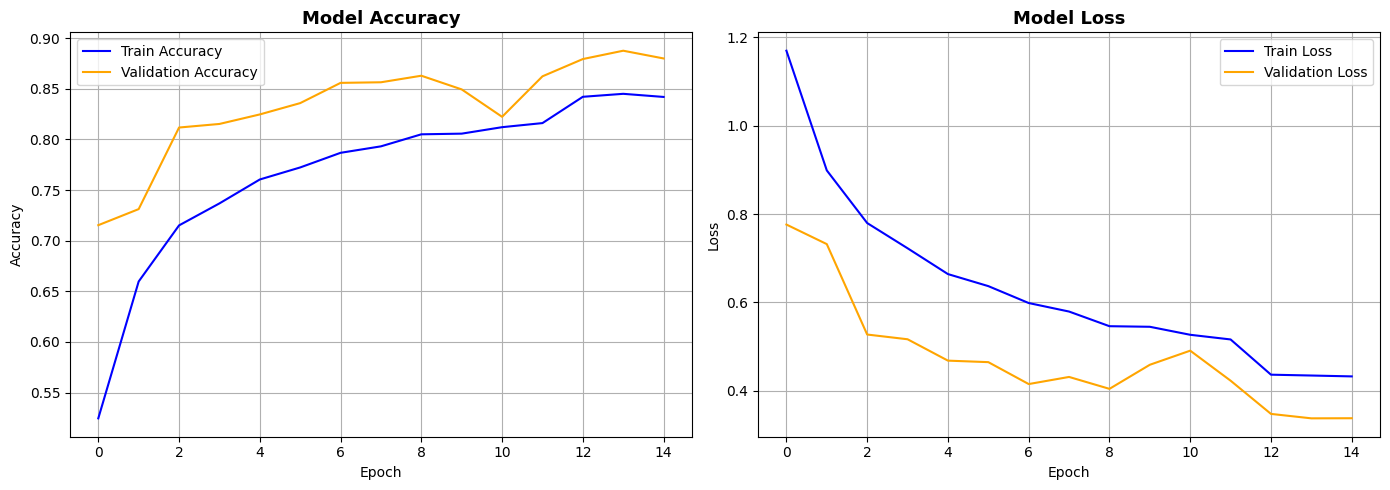

Plot disimpan ke training_plot.png


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Model Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss',      color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan ke training_plot.png')

## 8. Evaluasi Model

In [11]:
print('=== Evaluasi pada Test Set ===')
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'\nTest Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

print('\n=== Evaluasi pada Train Set ===')
train_loss, train_acc = model.evaluate(train_generator, verbose=1)
print(f'\nTrain Loss    : {train_loss:.4f}')
print(f'Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)')

print('\n=== Cek Kriteria Submission ===')
print(f'Train Accuracy >= 85%: {"✓ PASS" if train_acc >= 0.85 else "✗ FAIL"} ({train_acc*100:.2f}%)')
print(f'Test  Accuracy >= 85%: {"✓ PASS" if test_acc  >= 0.85 else "✗ FAIL"} ({test_acc*100:.2f}%)')

=== Evaluasi pada Test Set ===
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8730 - loss: 0.3553

Test Loss    : 0.3553
Test Accuracy: 0.8730 (87.30%)

=== Evaluasi pada Train Set ===
426/426 ━━━━━━━━━━━━━━━━━━━━ 90s 212ms/step - accuracy: 0.8639 - loss: 0.3783

Train Loss    : 0.3783
Train Accuracy: 0.8639 (86.39%)

=== Cek Kriteria Submission ===
Train Accuracy >= 85%: ✓ PASS (86.39%)
Test  Accuracy >= 85%: ✓ PASS (87.30%)


## 9. Simpan Model

### 9a. SavedModel Format

In [12]:
SAVED_MODEL_PATH = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification/saved_model'
os.makedirs(SAVED_MODEL_PATH, exist_ok=True)
model.export(SAVED_MODEL_PATH)
print(f'SavedModel disimpan ke: {SAVED_MODEL_PATH}')
print('Isi:', os.listdir(SAVED_MODEL_PATH))

Saved artifact at '/content/drive/MyDrive/Fundamental deaplearning/imageclasification/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140249661449872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249661445072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249663847696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249663847504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249663847888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249661451408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249663832144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249661453904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249661454096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249661449680: Tenso

### 9b. TF-Lite Format

In [13]:
converter    = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_PATH)
tflite_model = converter.convert()

TFLITE_PATH = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification/tflite/model.tflite'
os.makedirs(os.path.dirname(TFLITE_PATH), exist_ok=True)
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f'TF-Lite disimpan ke: {TFLITE_PATH}')
print(f'Ukuran: {os.path.getsize(TFLITE_PATH)/1024:.1f} KB')

TF-Lite disimpan ke: /content/drive/MyDrive/Fundamental deaplearning/imageclasification/tflite/model.tflite
Ukuran: 26624.6 KB



### 9c. TensorFlow.js Format

In [14]:
!pip install tensorflowjs==4.17.0 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 9.0 MB/s eta 0:00:00


In [15]:
conv_path = '/usr/local/lib/python3.13/dist-packages/tensorflowjs/converters/tf_saved_model_conversion_v2.py'

with open(conv_path, 'r') as f:
    content = f.read()

old_line = 'import tensorflow_decision_forests'
new_block = (
    'try:\n'
    '    import tensorflow_decision_forests\n'
    'except ImportError:\n'
    '    tensorflow_decision_forests = None\n'
)

if old_line in content and 'tensorflow_decision_forests = None' not in content:
    content = content.replace(old_line, new_block)
    with open(conv_path, 'w') as f:
        f.write(content)
    print('Patch berhasil')
else:
    print('Sudah dipatch atau baris tidak ditemukan')

Patch berhasil


In [16]:
import tensorflowjs as tfjs

TFJS_PATH = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification/tfjs_model'
os.makedirs(TFJS_PATH, exist_ok=True)
tfjs.converters.save_keras_model(model, TFJS_PATH)

print(f'TFJS disimpan ke: {TFJS_PATH}')
print('Isi:', os.listdir(TFJS_PATH))

failed to lookup keras version from the file,
    this is likely a weight only file
TFJS disimpan ke: /content/drive/MyDrive/Fundamental deaplearning/imageclasification/tfjs_model
Isi: ['group1-shard1of7.bin', 'group1-shard7of7.bin', 'group1-shard3of7.bin', 'group1-shard4of7.bin', 'group1-shard5of7.bin', 'group1-shard2of7.bin', 'group1-shard6of7.bin', 'model.json']


## 10. Verifikasi Semua File Submission

In [17]:
BASE_PATH = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification'

# 1. tflite/label.txt
label_path = f'{BASE_PATH}/tflite/label.txt'
os.makedirs(os.path.dirname(label_path), exist_ok=True)
with open(label_path, 'w') as f:
    for cls in CLASS_NAMES:
        f.write(cls + '\n')
print(f'Label tersimpan: {label_path}')

Label tersimpan: /content/drive/MyDrive/Fundamental deaplearning/imageclasification/tflite/label.txt


In [18]:
BASE_PATH = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification'
req_path = f'{BASE_PATH}/requirements.txt'

!pip freeze | grep -iE "^(tensorflow|tf-keras|numpy|matplotlib|pillow|tensorflowjs|keras)" > "{req_path}"

with open(req_path) as f:
    print(f.read())

keras==3.13.2
keras-hub==0.26.0
keras-nlp==0.26.0
matplotlib==3.10.0
matplotlib-inline==0.2.2
matplotlib-venn==1.1.2
numpy==2.1.3
pillow==11.3.0
tensorflow==2.20.0
tensorflow-datasets==4.9.10
tensorflow-hub==0.16.1
tensorflow-metadata==1.21.0
tensorflow-probability==0.25.0
tensorflow-text==2.20.1
tensorflowjs==4.17.0



In [19]:
BASE_PATH = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification'

readme_path = f'{BASE_PATH}/README.md'
readme_content = f"""# Image Classification — Intel Image Classification Dataset

## Deskripsi
Model klasifikasi gambar CNN Sequential untuk mengklasifikasikan 6 kategori pemandangan:
buildings, forest, glacier, mountain, sea, street.

## Dataset
Intel Image Classification (Kaggle). Seluruh gambar dari folder bawaan `seg_train` dan `seg_test`
digabungkan terlebih dahulu, lalu displit ulang secara mandiri (stratified, seed={SEED}) menjadi:
- Train: 80%
- Validation: 10%
- Test: 10%

Total gambar gabungan: {total}
Total gambar test (hasil split mandiri): {total_test}

## Arsitektur Model
CNN Sequential dengan 4 blok Conv2D + MaxPooling2D, diikuti Flatten, Dense, Dropout, dan Softmax output.

## Hasil
- Train Accuracy: {train_acc*100:.2f}%
- Test Accuracy: {test_acc*100:.2f}%

## Format Model
- SavedModel: `saved_model/`
- TensorFlow Lite: `tflite/model.tflite` (label di `tflite/label.txt`)
- TensorFlow.js: `tfjs_model/`

## Cara Menjalankan
1. Install dependencies: `pip install -r requirements.txt`
2. Load model sesuai format yang dibutuhkan (SavedModel/TFLite/TFJS)
"""
os.makedirs(BASE_PATH, exist_ok=True)
with open(readme_path, 'w') as f:
    f.write(readme_content)
print(f'README.md tersimpan: {readme_path}')

README.md tersimpan: /content/drive/MyDrive/Fundamental deaplearning/imageclasification/README.md


In [20]:
BASE_PATH = '/content/drive/MyDrive/Fundamental deaplearning/imageclasification'

print('=== Struktur Submission ===')

checks = {
    'saved_model/saved_model.pb': os.path.exists(f'{BASE_PATH}/saved_model/saved_model.pb'),
    'tflite/model.tflite'       : os.path.exists(f'{BASE_PATH}/tflite/model.tflite'),
    'tflite/label.txt'          : os.path.exists(f'{BASE_PATH}/tflite/label.txt'),
    'tfjs_model/model.json'     : os.path.exists(f'{BASE_PATH}/tfjs_model/model.json'),
    'requirements.txt'          : os.path.exists(f'{BASE_PATH}/requirements.txt'),
    'README.md'                 : os.path.exists(f'{BASE_PATH}/README.md'),
}

all_ok = True
for path, exists in checks.items():
    status = '✓' if exists else '✗ MISSING'
    if not exists:
        all_ok = False
    print(f'  {status}  {path}')

print()
print('Semua file lengkap!' if all_ok else 'Ada file yang belum ada!')

=== Struktur Submission ===
  ✓  saved_model/saved_model.pb
  ✓  tflite/model.tflite
  ✓  tflite/label.txt
  ✓  tfjs_model/model.json
  ✓  requirements.txt
  ✓  README.md

Semua file lengkap!


## 11. Prediksi Contoh

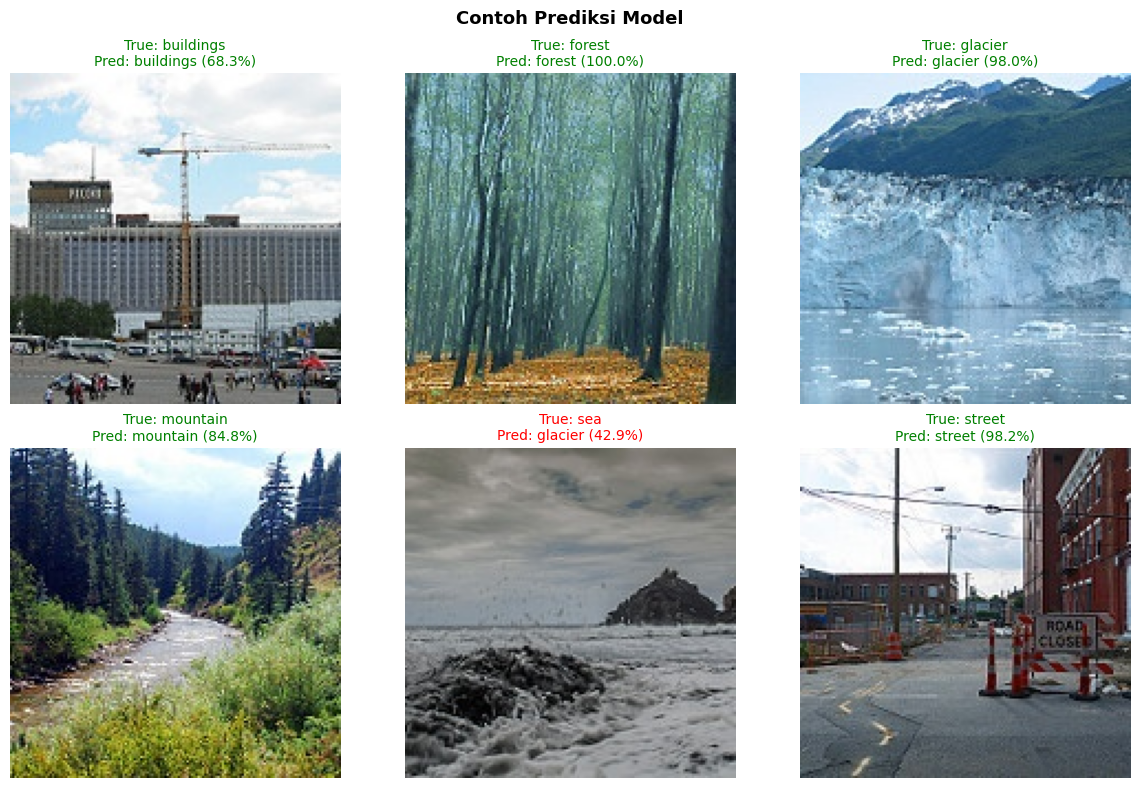

In [21]:

from tensorflow.keras.preprocessing import image as keras_image

CLASS_LABELS = list(train_generator.class_indices.keys())

def predict_image(img_path):
    img  = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    pred = model.predict(arr, verbose=0)
    idx  = np.argmax(pred[0])
    return CLASS_LABELS[idx], pred[0][idx]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir  = os.path.join(TEST_DIR, cls)
    img_path = os.path.join(cls_dir, os.listdir(cls_dir)[0])
    pred_cls, confidence = predict_image(img_path)

    img   = plt.imread(img_path)
    color = 'green' if pred_cls == cls else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f'True: {cls}\nPred: {pred_cls} ({confidence*100:.1f}%)', color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle('Contoh Prediksi Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()